In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import seaborn as sns
import matplotlib.pyplot as plt
import STAVelo as stv
stv.settings.verbosity = 3
stv.settings.presenter_view = True
stv.set_figure_params("scvelo")
import warnings
warnings.filterwarnings("ignore")

# Read data

In [2]:
data_path="../data/T3_Chicken_Heart_Visium_Day14/"
adata=sc.read(data_path+"Visium_D14_adata.h5ad")
adata.obsm["spatial"]=adata.obsm["X_xy_loc"]
from scipy.sparse import csr_matrix
adata.layers["spliced"] = csr_matrix(adata.layers["spliced"])
adata.layers["unspliced"] = csr_matrix(adata.layers["unspliced"])

# Run model

In [3]:
stv.show_proportions(adata)
adata

Abundance of ['unspliced', 'spliced']: [0.11 0.89]


AnnData object with n_obs × n_vars = 1967 × 12295
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'percent.mito', 'Spatial_snn_res.1', 'seurat_clusters', 'scanorama_snn_res.1', 'Cardiomyocytes-1', 'Cardiomyocytes-2', 'Immature.myocardial.cells', 'Valve.cells', 'Macrophages', 'Fibroblast.cells', 'Erythrocytes', 'Endocardial.cells', 'MT-enriched.cardiomyocytes', 'Epi-epithelial.cells', 'Vascular.endothelial.cells', 'TMSB4X.high.cells', 'Epi-mesenchymal.cells', 'Dendritic.cells', 'Mural.cells', 'max', 'celltype_prediction_max', 'celltype_prediction', 'celltype_prediction_mode', 'region', 'n_counts'
    var: 'gene_ids', 'n_cells', 'gene_count_corr'
    uns: 'celltype_prediction_colors'
    obsm: 'X_xy_loc', 'spatial'
    layers: 'spliced', 'unspliced'

In [4]:
stv.filter_and_normalize(adata, min_shared_counts=2, n_top_genes=1000)
stv.moments(adata, n_pcs=30, n_neighbors=30)

Filtered out 6365 genes that are detected 2 counts (shared).
Extracted 1000 highly variable genes.
computing neighbors
    finished (0:00:11) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [5]:
stv.Cal_Spatial_Net(adata, rad_cutoff=300)

------Calculating spatial graph...
The graph contains 11462 edges, 1967 cells.
5.8271 neighbors per cell on average.


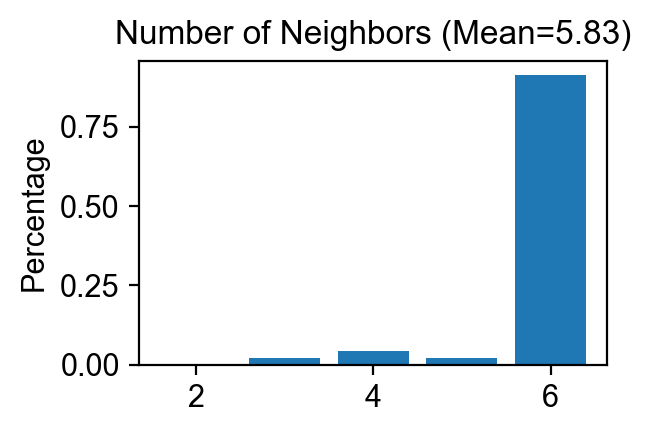

In [6]:
stv.Stats_Spatial_Net(adata)

In [7]:
adata = stv.train_STAVelo(adata, loss_type="cosine", w1 = 1, w2 = 1, random_seed=0, device = 'cuda:0')

Size of Input:  (1967, 1000)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:06<00:00, 150.04it/s]


In [8]:
stv.velocity_graph(adata, n_neighbors=500, n_jobs=16)

computing velocity graph (using 16/384 cores)


  0%|          | 0/1967 [00:00<?, ?cells/s]

    finished (0:00:04) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# Velocity visualization

In [9]:
#adata=sc.read("./result/adata.h5ad")

Renamed 'spatial' to convention 'X_spatial' (adata.obsm).
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


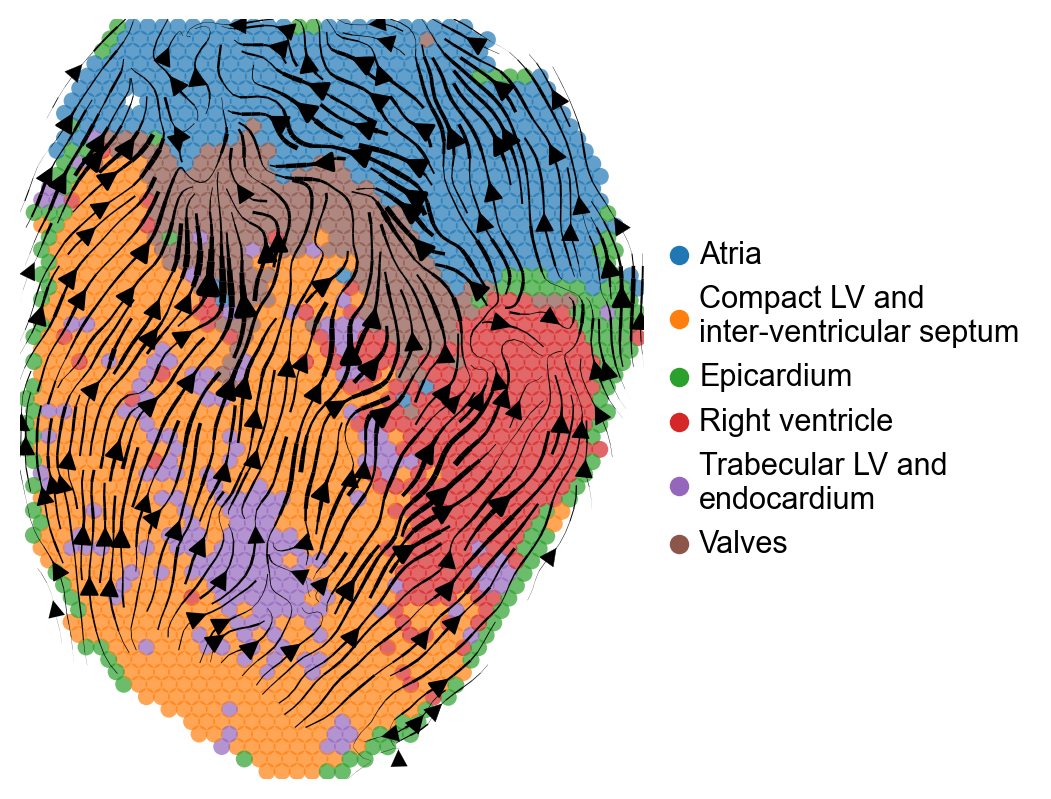

In [10]:
plt.rcParams["figure.figsize"] = (4, 5)
stv.velocity_embedding_stream(adata, basis='spatial', color="region", title="", legend_loc="right", alpha=0.7, size=150,
                              linewidth=1.5, arrow_size=1.5)

In [11]:
#if not os.path.exists("./result"):
#    os.makedirs("./result")
#adata.write("./result/adata.h5ad")

# Pseudotime

In [12]:
adata.obs['spatial_y'] = adata.obsm['spatial'][:, 1]
root_barcodes = adata.obs.nsmallest(10, 'spatial_y').index
adata.obs['root'] = False
adata.obs.loc[root_barcodes, 'root'] = True
stv.latent_time(adata, vkey='velocity', root_key='root')

computing latent time using root as prior
    finished (0:00:00) --> added 
    'latent_time', shared time (adata.obs)


/mnt/disk3/lishang/work/STAVelo/github/STAVelo/STAVelo/temporal.py:803: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  idx_roots = idx_roots.astype(np.float) > 1 - 1e-3


(6937.0, 19290.0, 2512.8, 18434.2)

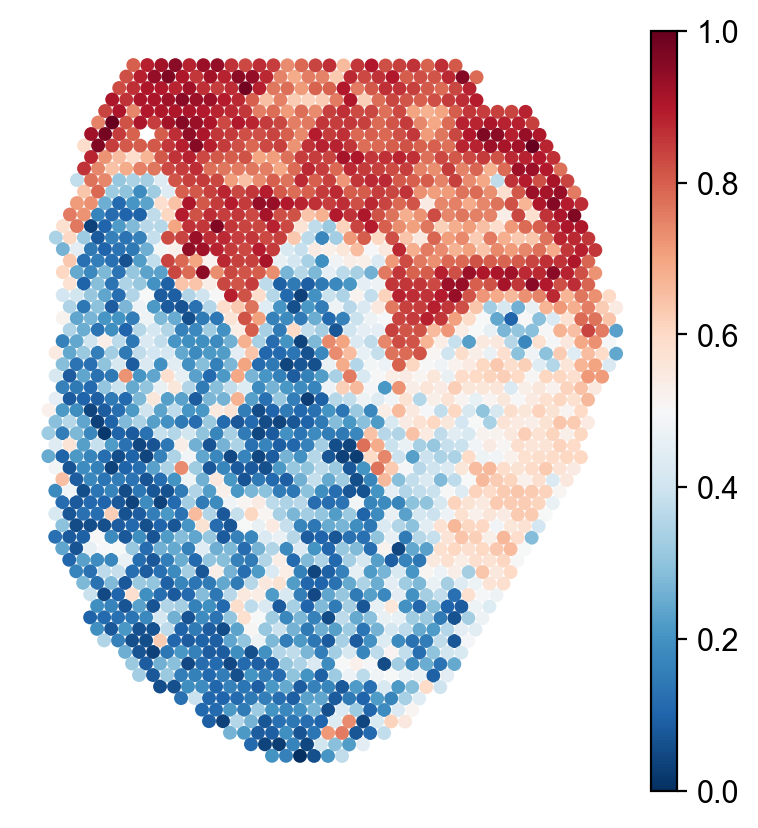

In [13]:
plt.rcParams["figure.figsize"] = (4.4, 5)
sc.pl.embedding(adata, basis="spatial", color="velocity_pseudotime", title="", s=100, show=False)
plt.axis('off')